### **AI Contract Intelligence System**

(NLP + Attention + Positional Encoding)


**Project Goal**

Build an AI system that understands legal contracts and automatically identifies critical clauses.

Examples:

Termination Clause

Payment Clause

Confidentiality Clause
Liability Clause

Non-Compete Clause


In [16]:
!apt-get install git-lfs -y
!git lfs install

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  git-lfs
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 3,544 kB of archives.
After this operation, 10.5 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 git-lfs amd64 3.0.2-1ubuntu0.3 [3,544 kB]
Fetched 3,544 kB in 0s (30.9 MB/s)
Selecting previously unselected package git-lfs.
(Reading database ... 118242 files and directories currently installed.)
Preparing to unpack .../git-lfs_3.0.2-1ubuntu0.3_amd64.deb ...
Unpacking git-lfs (3.0.2-1ubuntu0.3) ...
Setting up git-lfs (3.0.2-1ubuntu0.3) ...
Processing triggers for man-db (2.10.2-1) ...
Git LFS initialized.


In [17]:
!git clone https://huggingface.co/datasets/kiddothe2b/contract-nli

Cloning into 'contract-nli'...
remote: Enumerating objects: 22, done.
remote: Total 22 (delta 0), reused 0 (delta 0), pack-reused 22 (from 1)
Receiving objects: 100% (22/22), 4.68 KiB | 4.68 MiB/s, done.
Resolving deltas: 100% (9/9), done.


In [18]:
import os

for root, dirs, files in os.walk("contract-nli"):
    for file in files:
        print(os.path.join(root, file))

contract-nli/.gitattributes
contract-nli/contract_nli.zip
contract-nli/contract-nli.py
contract-nli/contract_nli_long.zip
contract-nli/README.md
contract-nli/.git/packed-refs
contract-nli/.git/HEAD
contract-nli/.git/index
contract-nli/.git/description
contract-nli/.git/config
contract-nli/.git/refs/remotes/origin/HEAD
contract-nli/.git/refs/heads/main
contract-nli/.git/hooks/push-to-checkout.sample
contract-nli/.git/hooks/pre-receive.sample
contract-nli/.git/hooks/post-update.sample
contract-nli/.git/hooks/post-merge
contract-nli/.git/hooks/pre-merge-commit.sample
contract-nli/.git/hooks/applypatch-msg.sample
contract-nli/.git/hooks/update.sample
contract-nli/.git/hooks/pre-commit.sample
contract-nli/.git/hooks/fsmonitor-watchman.sample
contract-nli/.git/hooks/prepare-commit-msg.sample
contract-nli/.git/hooks/pre-applypatch.sample
contract-nli/.git/hooks/commit-msg.sample
contract-nli/.git/hooks/post-checkout
contract-nli/.git/hooks/pre-push.sample
contract-nli/.git/hooks/post-commit
c

In [19]:
import zipfile

with zipfile.ZipFile("contract-nli/contract_nli.zip", "r") as zip_ref:
    zip_ref.extractall("contract_data")

print("Extracted")

Extracted


In [20]:
import os

for root, dirs, files in os.walk("contract_data"):
    for file in files:
        print(os.path.join(root, file))

contract_data/contract_nli_v1.jsonl
contract_data/__MACOSX/._contract_nli_v1.jsonl


In [22]:
import pandas as pd

df = pd.read_json(
    "contract_data/contract_nli_v1.jsonl",
    lines=True
)

In [23]:
df.head()

,premise,hypothesis,label,subset
0,2.3 Provided that the Recipient has a written ...,Receiving Party shall not reverse engineer any...,neutral,train
1,5. All Confidential Information in any form an...,Receiving Party shall destroy or return some C...,entailment,train
2,4. Nothing in this Agreement is to be construe...,Agreement shall not grant Receiving Party any ...,entailment,train
3,11. The Recipient shall not advertise or other...,Receiving Party shall not disclose the fact th...,entailment,train
4,"1. “Confidential Information”, whenever used i...",Confidential Information shall only include te...,neutral,train


In [24]:
df.shape

(9788, 4)

In [25]:
print(df.columns)

Index(['premise', 'hypothesis', 'label', 'subset'], dtype='object')


In [26]:
print(df.columns)
print(df.iloc[0])

Index(['premise', 'hypothesis', 'label', 'subset'], dtype='object')
premise       2.3 Provided that the Recipient has a written ...
hypothesis    Receiving Party shall not reverse engineer any...
label                                                   neutral
subset                                                    train
Name: 0, dtype: object


**Task 1: Dataset Investigation**

Perform EDA

Find:

Total contracts

Clause types

Average contract length

Longest contract

Shortest contract

Visualizations:

Clause distribution,
Word frequency,
Contract length histogram


In [27]:
#total contracts
total_contracts = len(df)
print("Total Contracts:", total_contracts)

Total Contracts: 9788


In [29]:
#clauses type
print(df['label'].unique())
print("\nClause Type Counts:")
print(df['label'].value_counts())

['neutral' 'entailment' 'contradiction']

Clause Type Counts:
label
entailment       4539
neutral          4146
contradiction    1103
Name: count, dtype: int64


In [30]:
#contract length
df['contract_length'] = df['premise'].apply(
    lambda x: len(str(x).split())
)
print(df[['contract_length']].head())

   contract_length
0              113
1               56
2               29
3               60
4               57


In [31]:
#average contract length
avg_length = df['contract_length'].mean()
print("Average Contract Length:", round(avg_length,2))

Average Contract Length: 98.72


In [32]:
#longest contract
longest_length = df['contract_length'].max()
print("Longest Contract Length:", longest_length)

Longest Contract Length: 429


In [34]:
longest_idx = df['contract_length'].idxmax()
print(df.loc[longest_idx,'premise'])

2. All Information identified as confidential and disclosed there under shall remain the sole property of the disclosing party, and the receiving party shall have no interest in or rights thereto except as set forth herein. 3. When receiving the Information each party agrees to maintain all such Information in strict confidence and to use at least the same measures to protect the same as that party uses to protect its own confidential information, including but not limited to:  restricting the information’s availability to employees, agents or consultants of the receiving party with a need to know, and making such disclosure only after they have agreed to abide by the terms and conditions of this Agreement,  prohibiting duplication of any such information without the prior written consent of the disclosing party, and  taking all necessary and reasonable precautions to prevent unauthorised disclosure. 4. With respect to the obligations of the receiving party to the protection and use

In [33]:
#shortest contract
shortest_length = df['contract_length'].min()
print("Shortest Contract Length:", shortest_length)

Shortest Contract Length: 5


In [35]:
shortest_idx = df['contract_length'].idxmin()
print(df.loc[shortest_idx,'premise'])

Article 3 shall survive termination. 


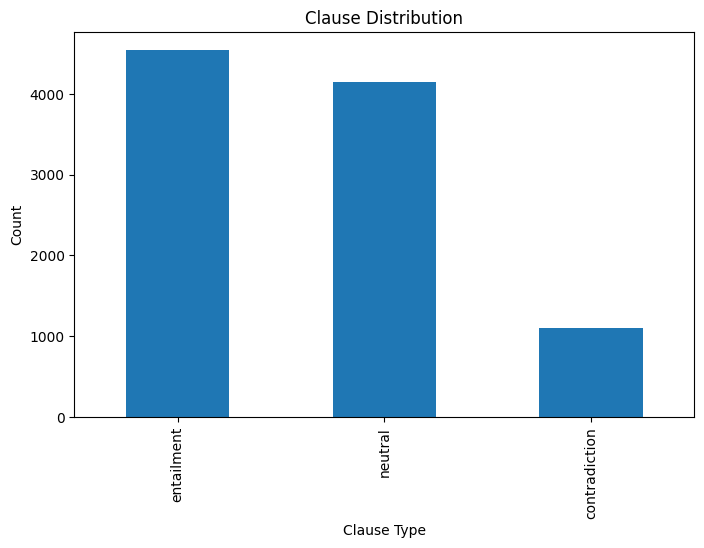

In [37]:
#clause distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df['label'].value_counts().plot(
    kind='bar'
)
plt.title("Clause Distribution")
plt.xlabel("Clause Type")
plt.ylabel("Count")
plt.show()

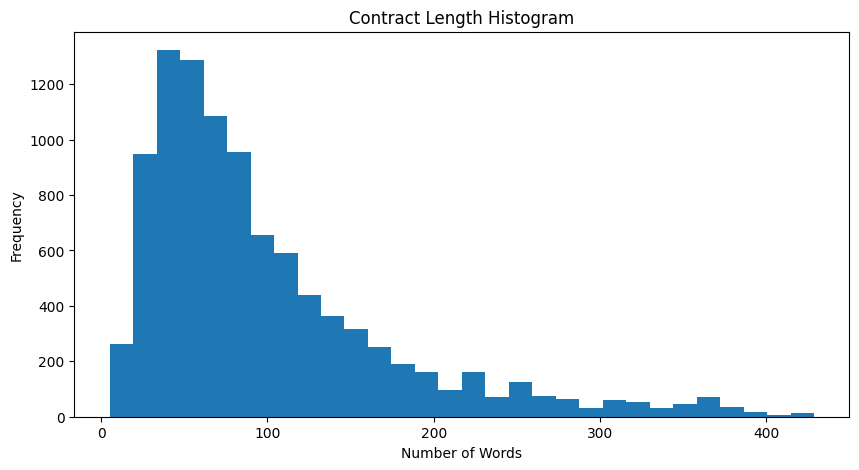

In [38]:
#contract length histogram
plt.figure(figsize=(10,5))
plt.hist(
    df['contract_length'],
    bins=30
)
plt.title("Contract Length Histogram")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [39]:
#word frequency analysis
from collections import Counter

all_text = " ".join(
    df['premise'].astype(str)
)
words = all_text.lower().split()
word_freq = Counter(words)
print(word_freq.most_common(20))

[('the', 67057), ('or', 39951), ('to', 36770), ('of', 36687), ('and', 22681), ('information', 21721), ('any', 19672), ('party', 18209), ('in', 16177), ('confidential', 15983), ('by', 14639), ('a', 11175), ('shall', 10482), ('other', 10272), ('receiving', 9860), ('that', 9532), ('is', 9527), ('such', 9175), ('not', 9145), ('this', 8640)]


In [41]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [42]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
filtered_words = [
    word
    for word in words
    if word.isalpha() and word not in stop_words
]
filtered_freq = Counter(filtered_words)
print(filtered_freq.most_common(20))

[('information', 21721), ('party', 18209), ('confidential', 15983), ('shall', 10482), ('receiving', 9860), ('disclosing', 8056), ('agreement', 4745), ('recipient', 4712), ('without', 4366), ('disclosure', 4122), ('use', 3590), ('written', 3577), ('disclose', 3403), ('disclosed', 3233), ('may', 2979), ('prior', 2887), ('third', 2881), ('representatives', 2712), ('proprietary', 2636), ('business', 2530)]


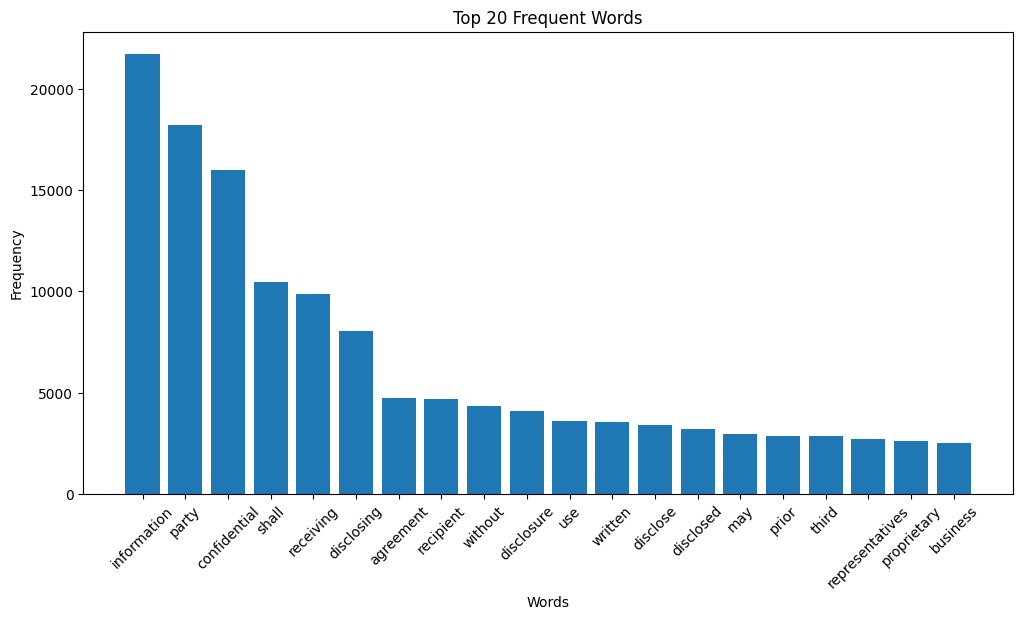

In [43]:
#word frequency visulaization
top_words = filtered_freq.most_common(20)

word_list = [w[0] for w in top_words]
count_list = [w[1] for w in top_words]

plt.figure(figsize=(12,6))
plt.bar(word_list, count_list)
plt.xticks(rotation=45)
plt.title("Top 20 Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

**Task 2: Text Engineering**

Perform:

Cleaning

Tokenization

Vocabulary Creation

Sequence Padding

OOV Handling



In [44]:
#cleaning
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['clean_text'] = df['premise'].apply(clean_text)
df[['premise','clean_text']].head()

,premise,clean_text
0,2.3 Provided that the Recipient has a written ...,provided that the recipient has a written agre...
1,5. All Confidential Information in any form an...,all confidential information in any form and a...
2,4. Nothing in this Agreement is to be construe...,nothing in this agreement is to be construed a...
3,11. The Recipient shall not advertise or other...,the recipient shall not advertise or otherwise...
4,"1. “Confidential Information”, whenever used i...",confidential information whenever used in this...


In [45]:
#tokenization
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(
    df['clean_text']
)
print(sequences[0][:20])

[42, 15, 1, 28, 81, 12, 36, 20, 27, 1, 226, 237, 2, 715, 1637, 630, 3, 436, 1, 9]


In [46]:
#vocabulary creation
word_index = tokenizer.word_index
print("Vocabulary Size:",
      len(word_index))

Vocabulary Size: 5210


In [47]:
for word,index in list(word_index.items())[:20]:
    print(word,"->",index)

the -> 1
or -> 2
to -> 3
of -> 4
information -> 5
party -> 6
and -> 7
any -> 8
confidential -> 9
in -> 10
by -> 11
a -> 12
shall -> 13
other -> 14
that -> 15
receiving -> 16
not -> 17
is -> 18
such -> 19
agreement -> 20


In [48]:
#sequence length analysis
sequence_lengths = [
    len(seq)
    for seq in sequences
]
print("Maximum Length:",
      max(sequence_lengths))
print("Average Length:",
      sum(sequence_lengths)/len(sequence_lengths))

Maximum Length: 421
Average Length: 97.6593788312219


In [49]:
#sequence padding
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length = 100
padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print("Shape:",
      padded_sequences.shape)
print(padded_sequences[0])

Shape: (9788, 100)
[  42   15    1   28   81   12   36   20   27    1  226  237    2  715
 1637  630    3  436    1    9    5   10  264   27   21   20    1   28
   43   38    1    9    5    3    8   14    6   27    1  313   46   36
  109    7    1  205   54 1899   34    7  112   70   71   12  469  130
    3  134    1 1038    4    1    9    5    7   54 1899   34    7  112
    4    8  127  218   15   37 1400 1400   37    2   27   33   37   18
   60 1259  440   70   71   12  178  130    3  134    1 1038    4    1
    9    5]


In [50]:
#OOV handling
oov_token = "<OOV>"
tokenizer_oov = Tokenizer(
    oov_token=oov_token
)
tokenizer_oov.fit_on_texts(
    df['clean_text']
)
test_text = [
    "cybersecurity payment agreement"
]
print(
    tokenizer_oov.texts_to_sequences(
        test_text
    )
)

[[1, 2000, 21]]


In [51]:
print(
    tokenizer_oov.word_index['<OOV>']
)

1


**Task 3: Baseline Model**

Architecture

Input

↓

Embedding

↓

Dense

↓

Output

Record:

Accuracy,
Precision,
Recall,
F1 Score



In [56]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['label'])
print(label_encoder.classes_)
print(y[:10])

['contradiction' 'entailment' 'neutral']
[2 1 1 1 2 1 1 1 2 1]


In [57]:
X = padded_sequences

print(X.shape)
print(y.shape)

(9788, 100)
(9788,)


In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)

(7830, 100)
(1958, 100)


In [59]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import GlobalAveragePooling1D
from tensorflow.keras.layers import Dense

vocab_size = len(tokenizer.word_index) + 1
model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=64,
        input_length=max_length
    ),
    GlobalAveragePooling1D(),
    Dense(
        64,
        activation='relu'
    ),
    Dense(
        3,
        activation='softmax'
    )
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.build(input_shape=(None, max_length))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 64)        │       333,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337,859 (1.29 MB)

 Trainable params: 337,859 (1.29 MB)

 Non-trainable params: 0 (0.00 B)

In [60]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4741 - loss: 0.9605 - val_accuracy: 0.4719 - val_loss: 0.9186
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5230 - loss: 0.8952 - val_accuracy: 0.5083 - val_loss: 0.8844
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5760 - loss: 0.8478 - val_accuracy: 0.5466 - val_loss: 0.8663
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6027 - loss: 0.8035 - val_accuracy: 0.5651 - val_loss: 0.8578
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6293 - loss: 0.7652 - val_accuracy: 0.5645 - val_loss: 0.8487
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.6429 - loss: 0.7361 - val_accuracy: 0.5613 - val_loss: 0.9067
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.6681 - loss: 0.7066 - val_accuracy: 0.5243 - val_loss: 0.9130
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.6721 - loss: 0.6854 - val_accur

In [61]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", accuracy)

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5557 - loss: 0.9183
Test Accuracy: 0.5556690692901611


In [62]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

y_pred_probs = model.predict(X_test)
y_pred = y_pred_probs.argmax(axis=1)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)
recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)
f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy : 0.5556690500510725
Precision: 0.5624860939113837
Recall   : 0.5556690500510725
F1 Score : 0.5539073658411184


In [63]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

               precision    recall  f1-score   support

contradiction       0.38      0.49      0.43       221
   entailment       0.59      0.66      0.62       908
      neutral       0.58      0.46      0.51       829

     accuracy                           0.56      1958
    macro avg       0.52      0.54      0.52      1958
 weighted avg       0.56      0.56      0.55      1958



**Task 4: Self-Attention Layer**

Architecture

Input

↓

Embedding

↓

MultiHeadAttention

↓

Dense

↓

Output


In [64]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['label'])
X = padded_sequences

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [66]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input,
    Embedding,
    MultiHeadAttention,
    GlobalAveragePooling1D,
    Dense
)
from tensorflow.keras.models import Model

vocab_size = len(tokenizer.word_index) + 1

inputs = Input(shape=(max_length,))

# Embedding Layer
embedding = Embedding(
    input_dim=vocab_size,
    output_dim=64
)(inputs)

# Self Attention
attention_output = MultiHeadAttention(
    num_heads=4,
    key_dim=64
)(
    embedding,
    embedding
)

# Pooling
pooled = GlobalAveragePooling1D()(attention_output)

# Dense Layer
dense = Dense(
    64,
    activation='relu'
)(pooled)

# Output Layer
outputs = Dense(
    3,
    activation='softmax'
)(dense)

model_attention = Model(
    inputs=inputs,
    outputs=outputs
)

model_attention.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_attention.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 100, 64)   │    333,504 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 100, 64)   │     66,368 │ embedding_2[0][0… │
│ (MultiHeadAttentio… │                   │            │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ multi_head_atten… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 3)         │        195 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 404,227 (1.54 MB)

 Trainable params: 404,227 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

In [67]:
history_attention = model_attention.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 57s 268ms/step - accuracy: 0.4639 - loss: 0.9382 - val_accuracy: 0.4815 - val_loss: 0.8945
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 87s 296ms/step - accuracy: 0.5061 - loss: 0.8714 - val_accuracy: 0.5249 - val_loss: 0.8673
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 61s 310ms/step - accuracy: 0.5741 - loss: 0.8066 - val_accuracy: 0.5568 - val_loss: 0.8695
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 68s 240ms/step - accuracy: 0.6290 - loss: 0.7414 - val_accuracy: 0.5639 - val_loss: 0.9047
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 36s 181ms/step - accuracy: 0.6635 - loss: 0.6927 - val_accuracy: 0.5556 - val_loss: 0.9362
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 41s 183ms/step - accuracy: 0.6861 - loss: 0.6539 - val_accuracy: 0.5524 - val_loss: 0.9658
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 33s 171ms/step - accuracy: 0.7019 - loss: 0.6221 - val_accuracy: 0.5549 - val_loss: 1.1034
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 35s 176ms/step - accuracy: 0.7149 - loss: 0

In [68]:
loss, accuracy = model_attention.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", accuracy)

62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.5552 - loss: 1.3097
Test Accuracy: 0.5551583170890808


In [69]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

y_pred_probs = model_attention.predict(X_test)
y_pred = y_pred_probs.argmax(axis=1)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)
recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)
f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step
Accuracy : 0.5551583248212462
Precision: 0.5618263047253734
Recall   : 0.5551583248212462
F1 Score : 0.5511418637984521


In [70]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

               precision    recall  f1-score   support

contradiction       0.40      0.37      0.38       221
   entailment       0.62      0.48      0.54       908
      neutral       0.54      0.68      0.60       829

     accuracy                           0.56      1958
    macro avg       0.52      0.51      0.51      1958
 weighted avg       0.56      0.56      0.55      1958



**Task 5: Positional Encoding**

Implement from scratch.

Must visualize:

Position 1

Position 2

Position 3

...
using heatmaps.


In [71]:
import numpy as np

def positional_encoding(max_position, d_model):
    pe = np.zeros((max_position, d_model))
    for pos in range(max_position):
        for i in range(0, d_model, 2):
            pe[pos, i] = np.sin(
                pos / (10000 ** ((2 * i) / d_model))
            )
            if i + 1 < d_model:
                pe[pos, i + 1] = np.cos(
                    pos / (10000 ** ((2 * i) / d_model))
                )
    return pe

In [72]:
max_position = 50
d_model = 64

pos_encoding = positional_encoding(
    max_position,
    d_model
)

print("Shape:", pos_encoding.shape)

Shape: (50, 64)


In [73]:
print(pos_encoding[0])

[0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1.
 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1.
 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1.]


In [74]:
print(pos_encoding[1])

[8.41470985e-01 5.40302306e-01 5.33168440e-01 8.46009110e-01
 3.10983593e-01 9.50415280e-01 1.76892186e-01 9.84230234e-01
 9.98334166e-02 9.95004165e-01 5.62044992e-02 9.98419278e-01
 3.16175064e-02 9.99500042e-01 1.77818569e-02 9.99841890e-01
 9.99983333e-03 9.99950000e-01 5.62338361e-03 9.99984189e-01
 3.16227239e-03 9.99995000e-01 1.77827847e-03 9.99998419e-01
 9.99999833e-04 9.99999500e-01 5.62341296e-04 9.99999842e-01
 3.16227761e-04 9.99999950e-01 1.77827940e-04 9.99999984e-01
 9.99999998e-05 9.99999995e-01 5.62341325e-05 9.99999998e-01
 3.16227766e-05 9.99999999e-01 1.77827941e-05 1.00000000e+00
 1.00000000e-05 1.00000000e+00 5.62341325e-06 1.00000000e+00
 3.16227766e-06 1.00000000e+00 1.77827941e-06 1.00000000e+00
 1.00000000e-06 1.00000000e+00 5.62341325e-07 1.00000000e+00
 3.16227766e-07 1.00000000e+00 1.77827941e-07 1.00000000e+00
 1.00000000e-07 1.00000000e+00 5.62341325e-08 1.00000000e+00
 3.16227766e-08 1.00000000e+00 1.77827941e-08 1.00000000e+00]


In [75]:
print(pos_encoding[2])

[ 9.09297427e-01 -4.16146837e-01  9.02130715e-01  4.31462829e-01
  5.91127117e-01  8.06578410e-01  3.48205276e-01  9.37418309e-01
  1.98669331e-01  9.80066578e-01  1.12231311e-01  9.93682109e-01
  6.32033979e-02  9.98000667e-01  3.55580908e-02  9.99367611e-01
  1.99986667e-02  9.99800007e-01  1.12465894e-02  9.99936755e-01
  6.32451316e-03  9.99980000e-01  3.55655132e-03  9.99993675e-01
  1.99999867e-03  9.99998000e-01  1.12468241e-03  9.99999368e-01
  6.32455490e-04  9.99999800e-01  3.55655875e-04  9.99999937e-01
  1.99999999e-04  9.99999980e-01  1.12468265e-04  9.99999994e-01
  6.32455532e-05  9.99999998e-01  3.55655882e-05  9.99999999e-01
  2.00000000e-05  1.00000000e+00  1.12468265e-05  1.00000000e+00
  6.32455532e-06  1.00000000e+00  3.55655882e-06  1.00000000e+00
  2.00000000e-06  1.00000000e+00  1.12468265e-06  1.00000000e+00
  6.32455532e-07  1.00000000e+00  3.55655882e-07  1.00000000e+00
  2.00000000e-07  1.00000000e+00  1.12468265e-07  1.00000000e+00
  6.32455532e-08  1.00000

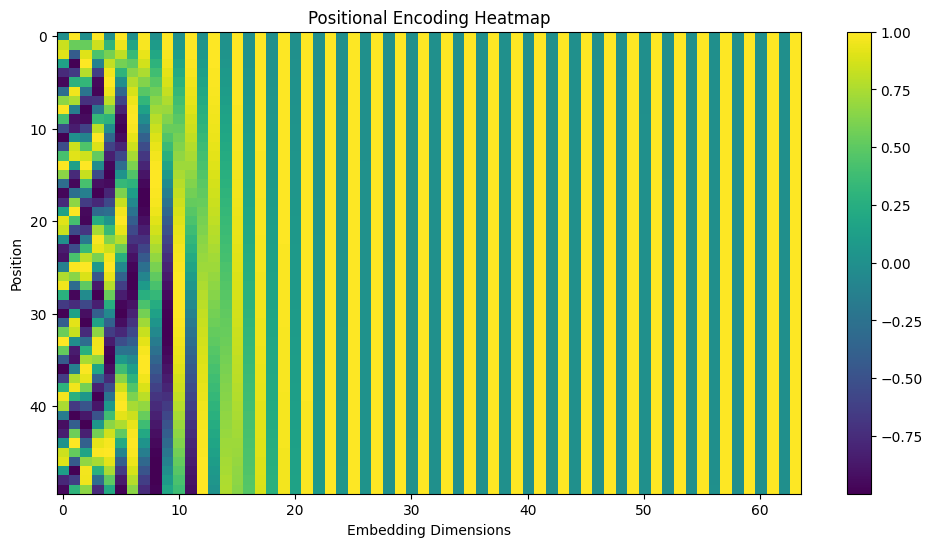

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.imshow(
    pos_encoding,
    cmap='viridis',
    aspect='auto'
)
plt.colorbar()
plt.xlabel("Embedding Dimensions")
plt.ylabel("Position")
plt.title("Positional Encoding Heatmap")
plt.show()

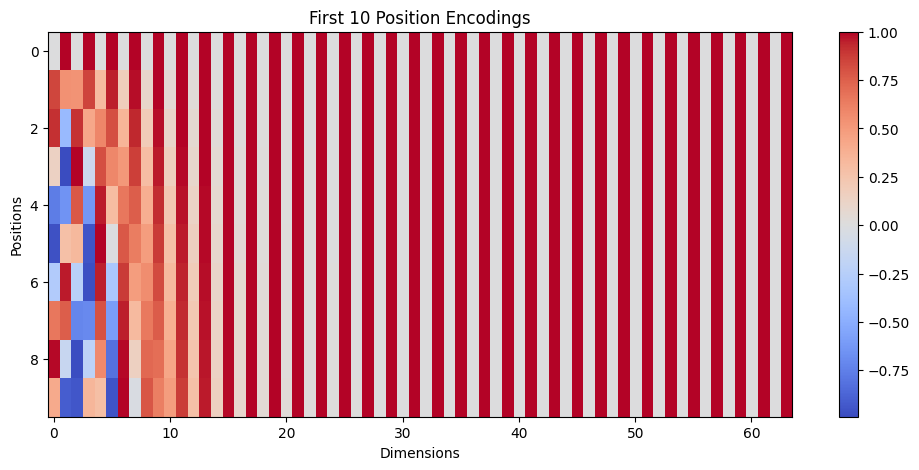

In [77]:
plt.figure(figsize=(12,5))
plt.imshow(
    pos_encoding[:10],
    cmap='coolwarm',
    aspect='auto'
)
plt.colorbar()
plt.xlabel("Dimensions")
plt.ylabel("Positions")
plt.title("First 10 Position Encodings")
plt.show()

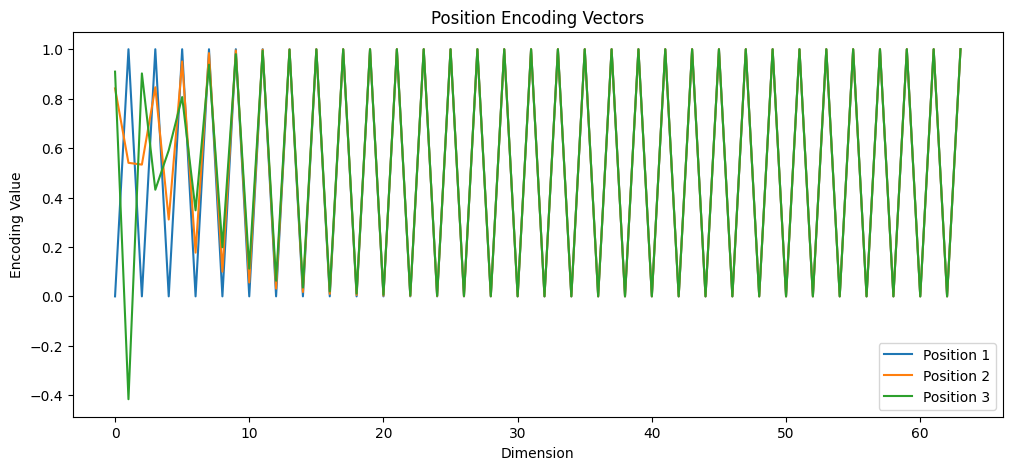

In [78]:
plt.figure(figsize=(12,5))
plt.plot(pos_encoding[0], label="Position 1")
plt.plot(pos_encoding[1], label="Position 2")
plt.plot(pos_encoding[2], label="Position 3")
plt.legend()
plt.title("Position Encoding Vectors")
plt.xlabel("Dimension")
plt.ylabel("Encoding Value")
plt.show()


**Task 6: Clause Understanding Analysis**

Contract A

Payment shall be made within 30 days.

Contract B

Within 30 days payment shall be made.



**Task 7: Attention Analysis**

Display:

Attention scores

Most important words

Example:

payment

termination

confidential


In [83]:
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import MultiHeadAttention
from tensorflow.keras.layers import GlobalAveragePooling1D
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Model

inputs = Input(shape=(max_length,))

embedding = Embedding(
    vocab_size,
    64
)(inputs)

attention_layer = MultiHeadAttention(
    num_heads=4,
    key_dim=64
)

attention_output, attention_scores = attention_layer(
    embedding,
    embedding,
    return_attention_scores=True
)

pooled = GlobalAveragePooling1D()(attention_output)

dense = Dense(
    64,
    activation='relu'
)(pooled)

outputs = Dense(
    3,
    activation='softmax'
)(dense)

attention_model = Model(
    inputs,
    outputs
)

In [84]:
attention_extractor = Model(
    inputs=attention_model.input,
    outputs=attention_scores
)

In [85]:
sample_text = """
payment shall be made within 30 days after invoice.
termination may occur if payment is not received.
all confidential information must remain protected.
"""

In [86]:
sample_text = df['clean_text'].iloc[0]

print(sample_text)

provided that the recipient has a written agreement with the following persons or entities requiring them to treat the confidential information in accordance with this agreement the recipient may disclose the confidential information to any other party with the disclosers prior written consent and the recipients employees officials representatives and agents who have a strict need to know the contents of the confidential information and employees officials representatives and agents of any legal entity that it controls controls it or with which it is under common control who have a similar need to know the contents of the confidential information provided that for these purposes a controlled legal entity means


In [87]:
sample_seq = tokenizer.texts_to_sequences([sample_text])

sample_pad = pad_sequences(
    sample_seq,
    maxlen=max_length,
    padding='post'
)

In [88]:
scores = attention_extractor.predict(
    sample_pad
)

print(scores.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
(1, 4, 100, 100)


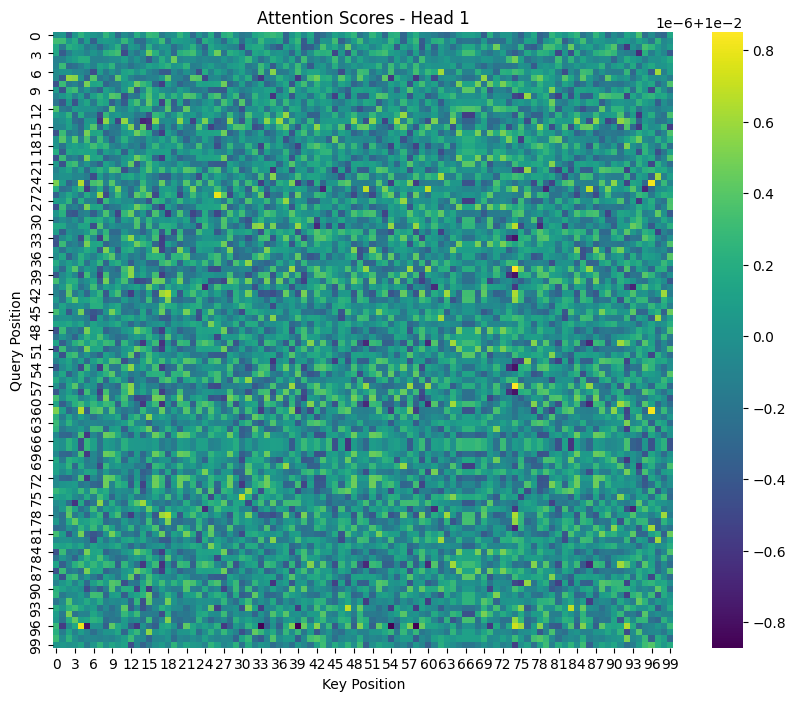

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

head_1 = scores[0][0]

plt.figure(figsize=(10,8))

sns.heatmap(
    head_1,
    cmap='viridis'
)

plt.title("Attention Scores - Head 1")
plt.xlabel("Key Position")
plt.ylabel("Query Position")

plt.show()

In [90]:
reverse_word_index = {
    v:k
    for k,v in tokenizer.word_index.items()
}

In [91]:
tokens = sample_pad[0]

words = []

for token in tokens:
    if token == 0:
        words.append("PAD")
    else:
        words.append(
            reverse_word_index.get(
                token,
                "UNK"
            )
        )

In [92]:
avg_attention = head_1.mean(axis=0)

In [93]:
import numpy as np

top_indices = np.argsort(
    avg_attention
)[-10:]

for idx in reversed(top_indices):
    print(
        words[idx],
        "->",
        avg_attention[idx]
    )

officials -> 0.010000054
officials -> 0.010000054
a -> 0.010000053
a -> 0.010000053
a -> 0.010000053
have -> 0.01000005
have -> 0.01000005
agreement -> 0.010000039
other -> 0.010000039
common -> 0.010000039


In [94]:
keywords = [
    "payment",
    "termination",
    "confidential"
]

for word in keywords:

    if word in words:

        pos = words.index(word)

        print("\nWord:", word)

        print(
            "Attention Score:",
            avg_attention[pos]
        )


Word: confidential
Attention Score: 0.010000025


In [95]:
model.save("contract_model.h5")

In [96]:
from google.colab import files
files.download("contract_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [97]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer_oov, f)

In [98]:
files.download("tokenizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [99]:
import pickle

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

In [100]:
files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>